In [22]:
!pip install numpy gensim gradio nltk wordcloud -q

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',  quiet=True)

True

In [23]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re, time, warnings
from collections import Counter
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling1D, Bidirectional, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
import gensim.downloader as gensim_api

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TF:', tf.__version__, '| GPU:', bool(tf.config.list_physical_devices('GPU')))


TF: 2.20.0 | GPU: True


In [25]:

DATA_PATH = '/content/drive/MyDrive/Assessment_AI/Book_review.csv'

df = pd.read_csv(DATA_PATH, on_bad_lines='skip')
df = df[['rating', 'reviewText', 'summary']].copy()
df.dropna(subset=['reviewText', 'rating'], inplace=True)
df['rating'] = df['rating'].astype(float).astype(int)
df = df[df['rating'].between(1, 5)].reset_index(drop=True)
df['summary'] = df['summary'].fillna('')

print(f'Dataset shape: {df.shape}')
print('\nRating distribution:')
print(df['rating'].value_counts().sort_index())
df.head(3)


Dataset shape: (12000, 3)

Rating distribution:
rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64


,rating,reviewText,summary
0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!


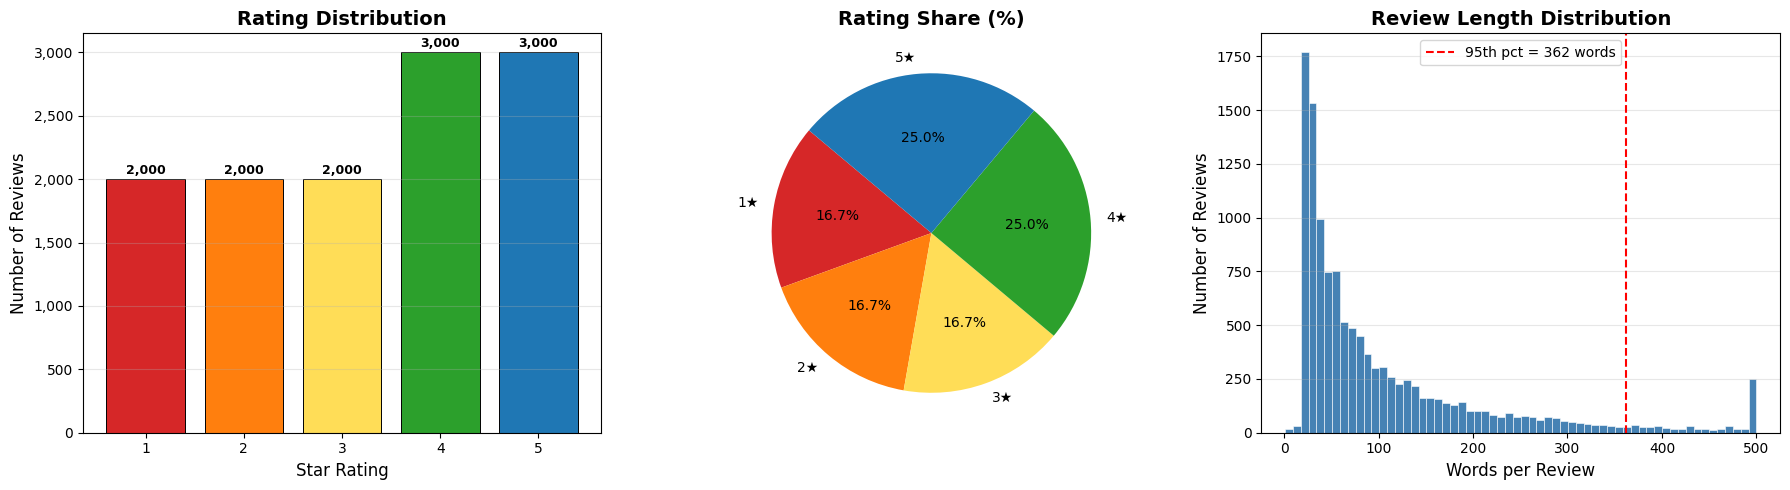

Review length stats:
count    12000.0
mean       109.2
std        126.1
min          1.0
25%         32.0
50%         62.0
75%        135.0
max       2156.0
Name: wc, dtype: float64


In [26]:
#  EDA: class distribution + review length
PALETTE = ['#d62728','#ff7f0e','#ffdd57','#2ca02c','#1f77b4']
counts  = df['rating'].value_counts().sort_index()
df['wc'] = df['reviewText'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=PALETTE,
                   edgecolor='black', linewidth=0.7)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Star Rating', fontsize=12)
axes[0].set_ylabel('Number of Reviews', fontsize=12)
axes[0].set_xticks([1,2,3,4,5])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{v:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=[f'{i}★' for i in counts.index],
            colors=PALETTE, autopct='%1.1f%%', startangle=140,
            textprops={'fontsize':10})
axes[1].set_title('Rating Share (%)', fontsize=14, fontweight='bold')

# Review length histogram
p95 = int(df['wc'].quantile(0.95))
axes[2].hist(df['wc'].clip(upper=500), bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[2].axvline(p95, color='red', linestyle='--', linewidth=1.5, label=f'95th pct = {p95} words')
axes[2].set_title('Review Length Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Words per Review', fontsize=12)
axes[2].set_ylabel('Number of Reviews', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Review length stats:')
print(df['wc'].describe().round(1))


In [27]:
MAX_PER_CLASS = 15_000
MIN_PER_CLASS = 5_000

df_bal = pd.concat([
    resample(
        df[df['rating'] == r],
        replace  = len(df[df['rating'] == r]) < MIN_PER_CLASS,
        n_samples= max(min(len(df[df['rating'] == r]), MAX_PER_CLASS), MIN_PER_CLASS),
        random_state=SEED
    )
    for r in range(1, 6)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Balanced class distribution:')
print(df_bal['rating'].value_counts().sort_index())
print('Total rows:', len(df_bal))


Balanced class distribution:
rating
1    5000
2    5000
3    5000
4    5000
5    5000
Name: count, dtype: int64
Total rows: 25000


In [28]:
STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()
CONTRACTIONS = {
    "won't":"will not", "can't":"cannot", "don't":"do not",
    "doesn't":"does not", "didn't":"did not", "isn't":"is not",
    "i'm":"i am", "i've":"i have", "it's":"it is",
    "that's":"that is", "they're":"they are", "you're":"you are",
    "we're":"we are", "wouldn't":"would not", "couldn't":"could not",
    "shouldn't":"should not", "aren't":"are not",
    "wasn't":"was not",  "weren't":"were not"
}

def clean_text(row):
    summary = str(row.get('summary','') or '')
    review  = str(row.get('reviewText','') or '')
    text = (summary + ' ') * 2 + review   # summary weighted double
    text = text.lower()
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    text = re.sub(r'http\S+|www\S+|<.*?>', '', text)  # URLs / HTML
    text = re.sub(r'@\w+', '', text)                    # @mentions
    text = re.sub(r'#\w+', '', text)                    # #hashtags
    text = re.sub(r'\d+', '', text)                     # numbers
    text = re.sub(r'[^a-z\s]', '', text)               # special chars
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split()
              if w not in STOP_WORDS and len(w) > 2]
    return ' '.join(tokens)

print('Cleaning text')
t0 = time.time()
df_bal['clean'] = df_bal.apply(clean_text, axis=1)
df_bal = df_bal[df_bal['clean'].str.len() > 5].reset_index(drop=True)
print(f'Done in {time.time()-t0:.1f}s')
print('\nBefore:', df_bal['reviewText'].iloc[0][:200])
print('\nAfter :', df_bal['clean'].iloc[0][:200])


Cleaning text
Done in 29.8s

Before: Though these be the tales of the brothers, the tales are incorrect.  These stories are happy tales while the tales written by the brothers were horrid and without a happy ending.

After : incorrect incorrect though tale brother tale incorrect story happy tale tale written brother horrid without happy ending


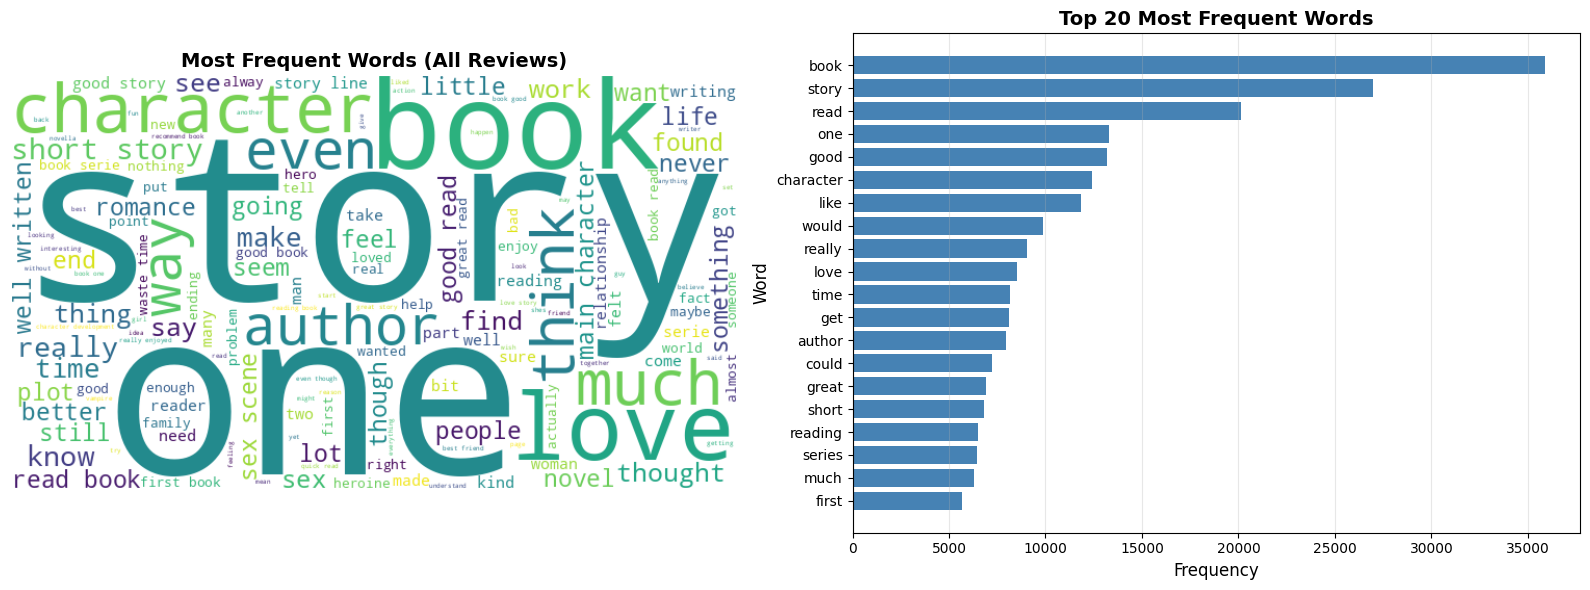

In [29]:
all_text  = ' '.join(df_bal['clean'].values)
word_freq = Counter(all_text.split())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc = WordCloud(width=700, height=400, background_color='white',
               colormap='viridis', max_words=150).generate(all_text)
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Most Frequent Words (All Reviews)', fontsize=14, fontweight='bold')

top20 = pd.DataFrame(word_freq.most_common(20), columns=['word','count'])
axes[1].barh(top20['word'][::-1], top20['count'][::-1], color='steelblue')
axes[1].set_xlabel('Frequency', fontsize=12)
axes[1].set_ylabel('Word', fontsize=12)
axes[1].set_title('Top 20 Most Frequent Words', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('wordcloud_top20.png', dpi=150, bbox_inches='tight')
plt.show()


In [30]:
# Tokenisation, padding, train/val/test split (70/15/15)
VOCAB_SIZE = 30_000
X = df_bal['clean'].values
y = df_bal['rating'].values - 1   # 0-indexed (0→4)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

tok = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tok.fit_on_texts(X_tr)            # fit on TRAIN only — no leakage
VOCAB   = min(VOCAB_SIZE, len(tok.word_index) + 1)
MAX_LEN = int(np.percentile([len(t.split()) for t in X_tr], 95))
print(f'VOCAB={VOCAB} | MAX_LEN={MAX_LEN} (95th percentile)')

def seq(texts):
    return pad_sequences(tok.texts_to_sequences(texts),
                         maxlen=MAX_LEN, padding='post', truncating='post')

X_tr_p  = seq(X_tr);  X_val_p = seq(X_val);  X_te_p = seq(X_te)
y_tr_c  = to_categorical(y_tr,  5)
y_val_c = to_categorical(y_val, 5)
y_te_c  = to_categorical(y_te,  5)

print(f'Train {X_tr_p.shape} | Val {X_val_p.shape} | Test {X_te_p.shape}')

# Class weights — computed from training labels only
cw_vals      = compute_class_weight('balanced', classes=np.arange(5), y=y_tr)
CLASS_WEIGHT = dict(enumerate(cw_vals))
print('Class weights:', {k: f'{v:.3f}' for k, v in CLASS_WEIGHT.items()})


VOCAB=30000 | MAX_LEN=188 (95th percentile)
Train (17500, 188) | Val (3750, 188) | Test (3750, 188)
Class weights: {0: '1.000', 1: '1.000', 2: '1.000', 3: '1.000', 4: '1.000'}


In [ ]:
#  Shared config + training curve plotter
EMBED_DIM = 128
BATCH     = 256

def make_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=3,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1)
    ]

def plot_history(history, title):
    eps  = range(1, len(history.history['loss']) + 1)
    loss = history.history['loss']
    vloss= history.history['val_loss']
    acc  = history.history['accuracy']
    vacc = history.history['val_accuracy']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    ax1.plot(eps, loss,  color='#1f77b4', marker='o', markersize=5,
             linewidth=1.8, label='Train Loss')
    ax1.plot(eps, vloss, color='#d62728', marker='o', markersize=5,
             linewidth=1.8, linestyle='--', label='Val Loss')
    ax1.set_title(f'{title}\nTrain vs Validation Loss',
                  fontsize=13, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Categorical Cross-Entropy Loss', fontsize=11)
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.35)
    ax1.text(0.98, 0.96,
             f'Best val loss: {min(vloss):.4f}',
             transform=ax1.transAxes, ha='right', va='top',
             fontsize=9, color='gray',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    # Accuracy
    ax2.plot(eps, acc,  color='#1f77b4', marker='o', markersize=5,
             linewidth=1.8, label='Train Accuracy')
    ax2.plot(eps, vacc, color='#d62728', marker='o', markersize=5,
             linewidth=1.8, linestyle='--', label='Val Accuracy')
    ax2.set_title(f'{title}\nTrain vs Validation Accuracy',
                  fontsize=13, fontweight='bold')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=11)
    ax2.set_ylim(0, 1.05)
    ax2.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
    ax2.yaxis.set_major_locator(mticker.MultipleLocator(0.1))
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.35)
    ax2.text(0.98, 0.04,
             f'Best val acc: {max(vacc)*100:.2f}%',
             transform=ax2.transAxes, ha='right', va='bottom',
             fontsize=9, color='gray',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

    plt.tight_layout()
    fname = title.replace(' ','_').replace('—','').replace('/','') + '_curves.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 188, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 188, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,881,989 (14.81 MB)

 Trainable params: 3,881,733 (14.81 MB)

 Non-trainable params: 256 (1.00 KB)


Training samples : 17,500
Model parameters : 3,881,989
Samples/param    : 0.0
Epoch 1/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.2147 - loss: 1.9539 - val_accuracy: 0.2600 - val_loss: 1.6143 - learning_rate: 3.0000e-04
Epoch 2/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2677 - loss: 1.6803 - val_accuracy: 0.3136 - val_loss: 1.6056 - learning_rate: 3.0000e-04
Epoch 3/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3530 - loss: 1.4984 - val_accuracy: 0.4168 - val_loss: 1.5628 - learning_rate: 3.0000e-04
Epoch 4/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4367 - loss: 1.3327 - val_accuracy: 0.5269 - val_loss: 1.4777 - learning_rate: 3.0000e-04
Epoch 5/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5137 - loss: 1.1706 - val_accuracy: 0.6333 - val_loss: 1.3277 - learning_rate: 3.0000e-04
Epoch 6/15
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5979 - loss: 1.0056 - val_accuracy: 0.6947 - val_loss: 1.1407 - learning_rate: 

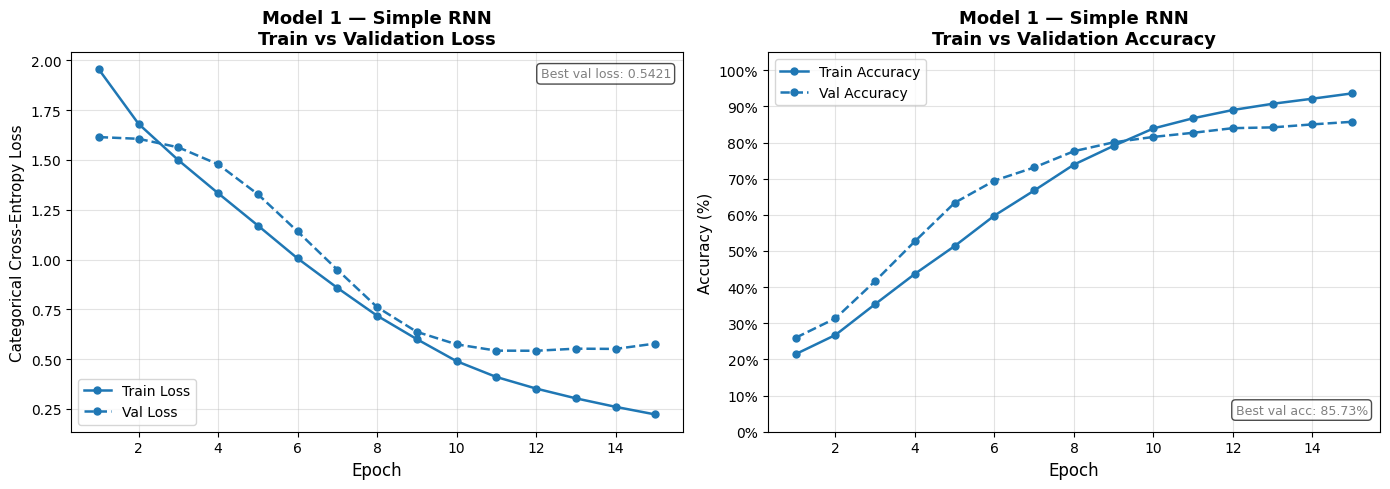

In [32]:
# Model 1: Simple RNN
model1 = Sequential(name='Model1_SimpleRNN', layers=[
    Embedding(VOCAB, EMBED_DIM, input_length=MAX_LEN, mask_zero=True),
    SimpleRNN(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2),
    GlobalAveragePooling1D(),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

model1.build(input_shape=(None, MAX_LEN))
model1.compile(optimizer=Adam(3e-4),
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model1.summary()

print(f'\nTraining samples : {len(X_tr_p):,}')
print(f'Model parameters : {model1.count_params():,}')
print(f'Samples/param    : {len(X_tr_p)/model1.count_params():.1f}')

t0 = time.time()
h1 = model1.fit(
    X_tr_p, y_tr_c,
    validation_data=(X_val_p, y_val_c),
    epochs=15,
    batch_size=BATCH,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks(),
    verbose=1
)
t1 = time.time() - t0
print(f'\nTraining time: {t1:.0f}s')
plot_history(h1, 'Model 1 — Simple RNN')

Model: "Model2_LSTM_Trainable"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 188, 64)        │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 188, 128)       │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,995,141 (7.61 MB)

 Trainable params: 1,994,885 (7.61 MB)

 Non-trainable params: 256 (1.00 KB)


Training samples : 17,500
Model parameters : 1,995,141
Samples/param    : 0.0
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.2523 - loss: 1.6771 - val_accuracy: 0.3131 - val_loss: 1.6841 - learning_rate: 3.0000e-04
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4411 - loss: 1.4507 - val_accuracy: 0.4349 - val_loss: 1.6179 - learning_rate: 3.0000e-04
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6187 - loss: 1.1847 - val_accuracy: 0.5501 - val_loss: 1.5422 - learning_rate: 3.0000e-04
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.7401 - loss: 1.0073 - val_accuracy: 0.6640 - val_loss: 1.4526 - learning_rate: 3.0000e-04
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8196 - loss: 0.8806 - val_accuracy: 0.7699 - val_loss: 1.3371 - learning_rate: 3.0000e-04
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8709 - loss: 0.7913 - val_accuracy: 0.8016 - val_loss: 1.2088 - learning_rate: 3.

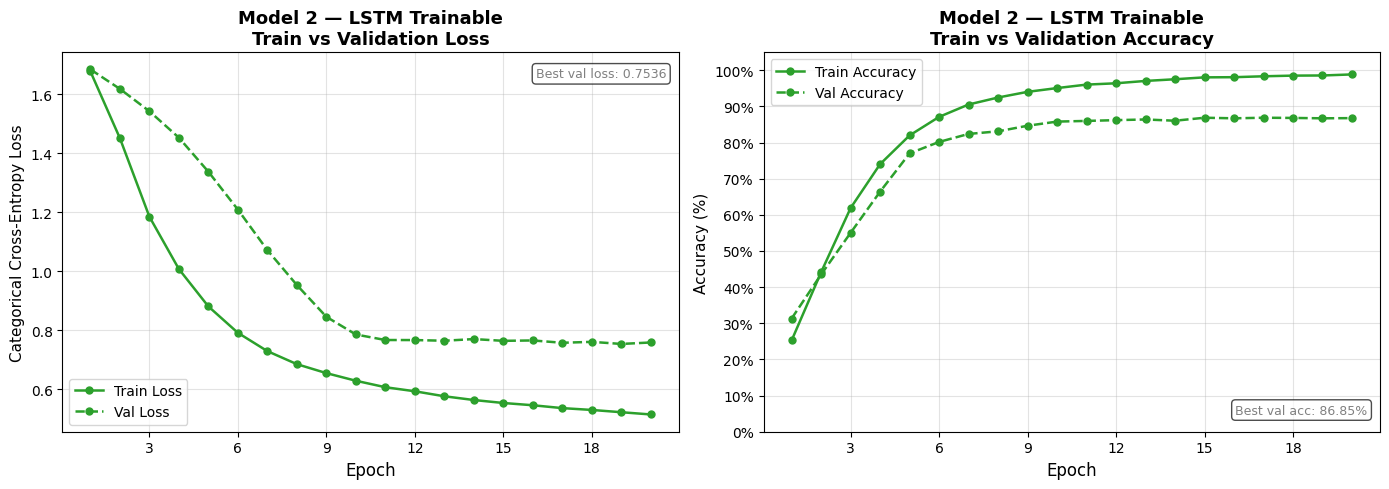

In [33]:
#Model 2: LSTM with Trainable Embedding (reduced capacity to prevent overfitting)
model2 = Sequential(name='Model2_LSTM_Trainable', layers=[
    Input(shape=(MAX_LEN,)),
    Embedding(VOCAB, 64, mask_zero=True),                        # 64 dim
    Bidirectional(LSTM(64, return_sequences=True,                # single BiLSTM (was stacked 128→64)
                       dropout=0.3)),
    GlobalAveragePooling1D(),
    BatchNormalization(),
    Dropout(0.5),                                                # stronger dropout (was 0.3)
    Dense(64, activation='relu', kernel_regularizer=l2(1e-3)),  # smaller head + L2 reg
    Dropout(0.4),                                               # stronger dropout (was 0.2)
    Dense(5, activation='softmax')
])

#  summary shows real shapes and param counts
model2.build(input_shape=(None, MAX_LEN))

model2.compile(
    optimizer=Adam(3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
model2.summary()

print(f'\nTraining samples : {len(X_tr_p):,}')
print(f'Model parameters : {model2.count_params():,}')
print(f'Samples/param    : {len(X_tr_p)/model2.count_params():.1f}')

t0 = time.time()
h2 = model2.fit(
    X_tr_p, y_tr_c,
    validation_data=(X_val_p, y_val_c),
    epochs=20,
    batch_size=BATCH,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks(),
    verbose=1
)
t2 = time.time() - t0
print(f'\nTraining time: {t2:.0f}s')
plot_history(h2, 'Model 2 — LSTM Trainable', color='#2ca02c')

In [34]:
glove = gensim_api.load('glove-wiki-gigaword-300')
GDIM  = 300

emb_matrix = np.zeros((VOCAB, GDIM))
found = 0
for word, idx in tok.word_index.items():
    if idx < VOCAB and word in glove:
        emb_matrix[idx] = glove[word]
        found += 1
print(f'Coverage: {found}/{VOCAB} = {found/VOCAB*100:.1f}%')


Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 188, 300)       │     9,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_19                │ (None, 188, 256)       │       439,296 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_20                │ (None, 188, 128)       │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_14     │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,629,253 (36.73 MB)

 Trainable params: 628,997 (2.40 MB)

 Non-trainable params: 9,000,256 (34.33 MB)


=== Phase 1: Frozen GloVe (30 epochs max) ===
Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - accuracy: 0.2656 - loss: 1.7116 - val_accuracy: 0.3288 - val_loss: 1.5761 - learning_rate: 3.0000e-04
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - accuracy: 0.3611 - loss: 1.4759 - val_accuracy: 0.4144 - val_loss: 1.5070 - learning_rate: 3.0000e-04
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 96ms/step - accuracy: 0.4011 - loss: 1.4053 - val_accuracy: 0.4680 - val_loss: 1.4403 - learning_rate: 3.0000e-04
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.4262 - loss: 1.3617 - val_accuracy: 0.4805 - val_loss: 1.3769 - learning_rate: 3.0000e-04
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.4482 - loss: 1.3313 - val_accuracy: 0.4728 - val_loss: 1.3267 - learning_rate: 3.0000e-04
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.4607 - loss: 1.3099 - val_accuracy: 0.5059 - val_loss: 1.2754 - learning_rate: 3.0000e-04
Epoch 7/20
69/69 ━━━━━

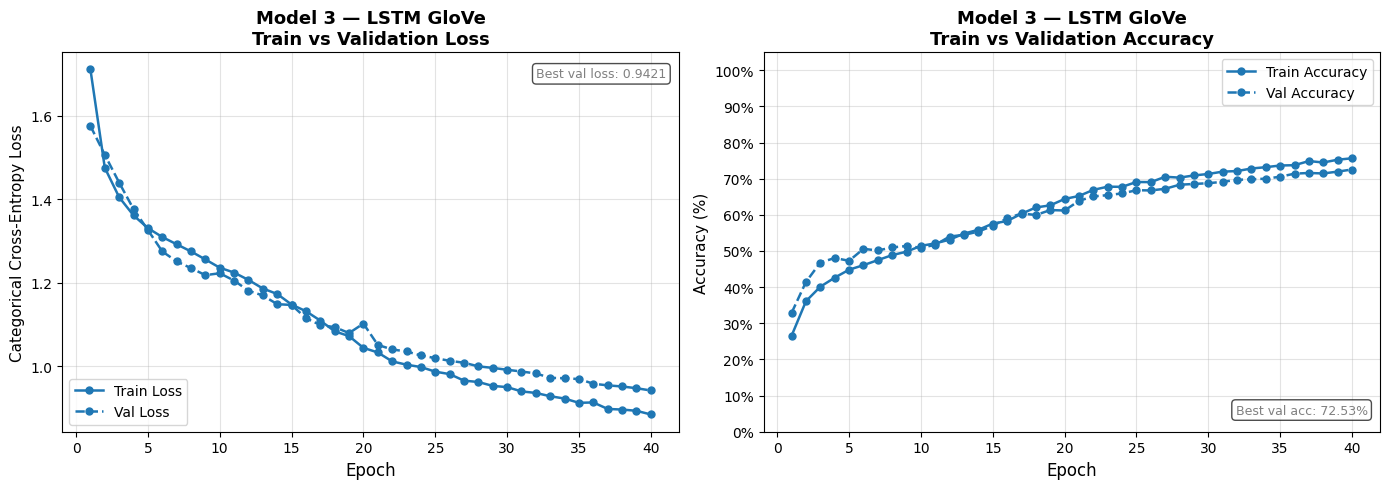

In [57]:
# Model 3: LSTM + GloVe-300d (two-phase training)
# frozen GloVe: train LSTM/Dense weights fast
# unfreeze GloVe: fine-tune at lower LR (avoid catastrophic forgetting)

model3 = Sequential(name='Model3_LSTM_GloVe', layers=[
    Embedding(VOCAB, GDIM, weights=[emb_matrix],
              input_length=MAX_LEN, trainable=False, mask_zero=True),
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2)),
    Bidirectional(LSTM(64,  return_sequences=True, dropout=0.2)),
    GlobalAveragePooling1D(),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64,  activation='relu'),
    Dropout(0.2),
    Dense(5, activation='softmax')
])

model3.build(input_shape=(None, MAX_LEN))
model3.compile(
    optimizer=Adam(3e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
model3.summary()

t0 = time.time()

#Frozen GloVe
print('\n=== Phase 1: Frozen GloVe (30 epochs max) ===')
h3a = model3.fit(
    X_tr_p, y_tr_c,
    validation_data=(X_val_p, y_val_c),
    epochs=20,
    batch_size=BATCH,
    class_weight=CLASS_WEIGHT,
    callbacks=make_callbacks(),
    verbose=1
)

#Fine-tune GloVe
print('\n=== Phase 2: Fine-tuning GloVe (20 epochs max) ===')
model3.layers[0].trainable = True
model3.compile(
    optimizer=Adam(3e-5),   # 10x lower than Phase 1 — prevents catastrophic forgetting
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
fine_cbs = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-7, verbose=1)
]
h3b = model3.fit(
    X_tr_p, y_tr_c,
    validation_data=(X_val_p, y_val_c),
    epochs=20,
    batch_size=BATCH,
    class_weight=CLASS_WEIGHT,
    callbacks=fine_cbs,
    verbose=1
)

t3 = time.time() - t0
print(f'\nTotal time (Phase 1 + 2): {t3:.0f}s ({t3/60:.1f} min)')

# Merge histories for one continuous plot
class MergedHistory:
    def __init__(self, h_list):
        self.history = {}
        for key in h_list[0].history:
            self.history[key] = []
            for h in h_list:
                self.history[key].extend(h.history[key])

h3 = MergedHistory([h3a, h3b])
plot_history(h3, 'Model 3 — LSTM GloVe')

In [58]:
# Evaluate all 3 models on test set
NAMES  = ['Simple RNN', 'LSTM Trainable', 'LSTM GloVe']
MODELS = [model1, model2, model3]
TIMES  = [t1, t2, t3]
STAR_LABELS = ['1★','2★','3★','4★','5★']
preds = []
accs  = []

for name, mdl in zip(NAMES, MODELS):
    yp  = np.argmax(mdl.predict(X_te_p, verbose=0), axis=1)
    acc = accuracy_score(y_te, yp)
    preds.append(yp)
    accs.append(acc)
    print(f'\n{"="*60}')
    print(f'  {name}   |   Test Accuracy: {acc*100:.2f}%')
    print('='*60)
    print(classification_report(y_te, yp, target_names=STAR_LABELS))



  Simple RNN   |   Test Accuracy: 83.41%
              precision    recall  f1-score   support

          1★       0.90      0.87      0.88       750
          2★       0.85      0.87      0.86       750
          3★       0.85      0.83      0.84       750
          4★       0.80      0.73      0.77       750
          5★       0.78      0.87      0.82       750

    accuracy                           0.83      3750
   macro avg       0.84      0.83      0.83      3750
weighted avg       0.84      0.83      0.83      3750


  LSTM Trainable   |   Test Accuracy: 86.61%
              precision    recall  f1-score   support

          1★       0.89      0.91      0.90       750
          2★       0.87      0.88      0.88       750
          3★       0.88      0.87      0.87       750
          4★       0.84      0.81      0.82       750
          5★       0.85      0.86      0.86       750

    accuracy                           0.87      3750
   macro avg       0.87      0.87      0.87

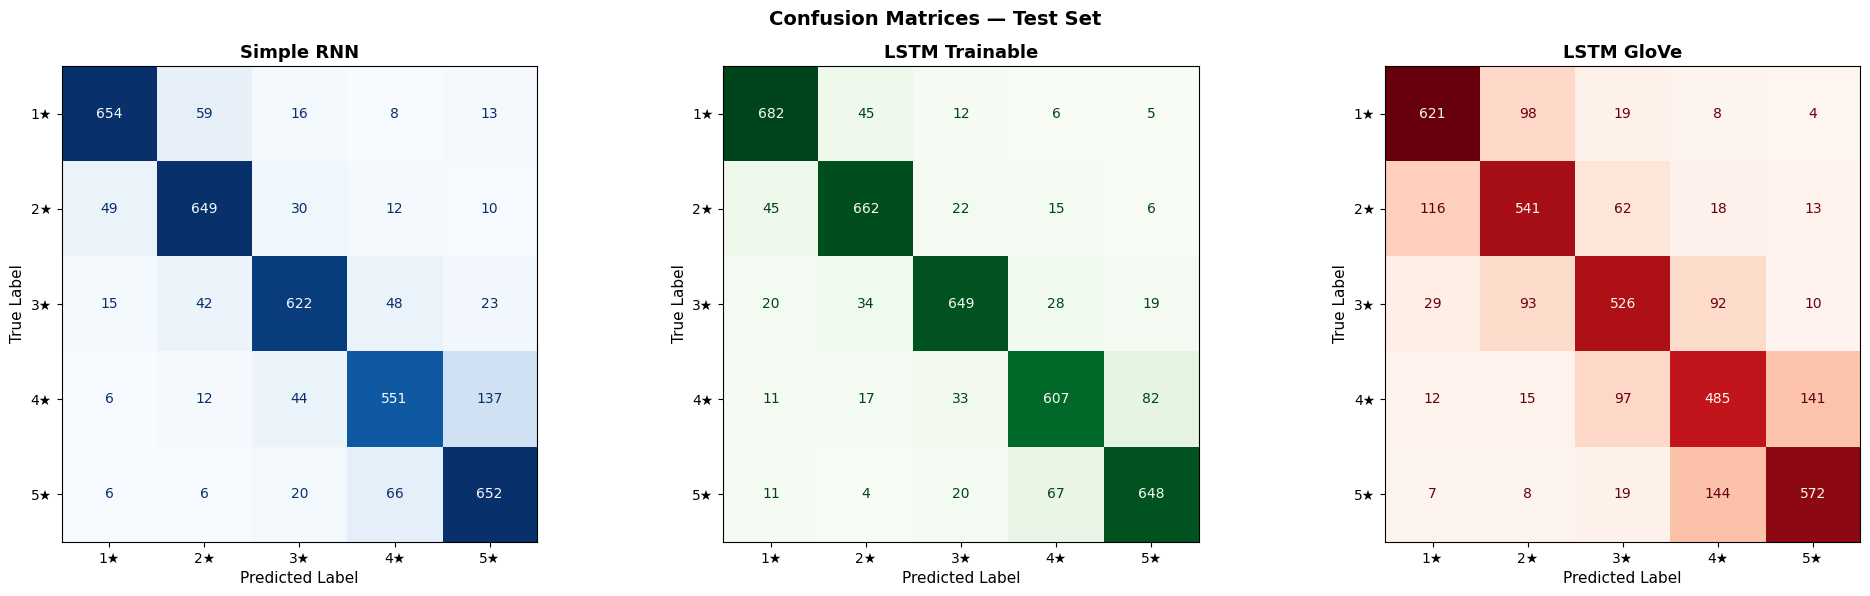

In [63]:
#  Confusion matrices (all 3 models side-by-side)
STAR_LABELS = ['1★','2★','3★','4★','5★']
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, yp, name, cmap in zip(axes, preds, NAMES, ['Blues','Greens','Reds']):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, yp),
        display_labels=STAR_LABELS
    ).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


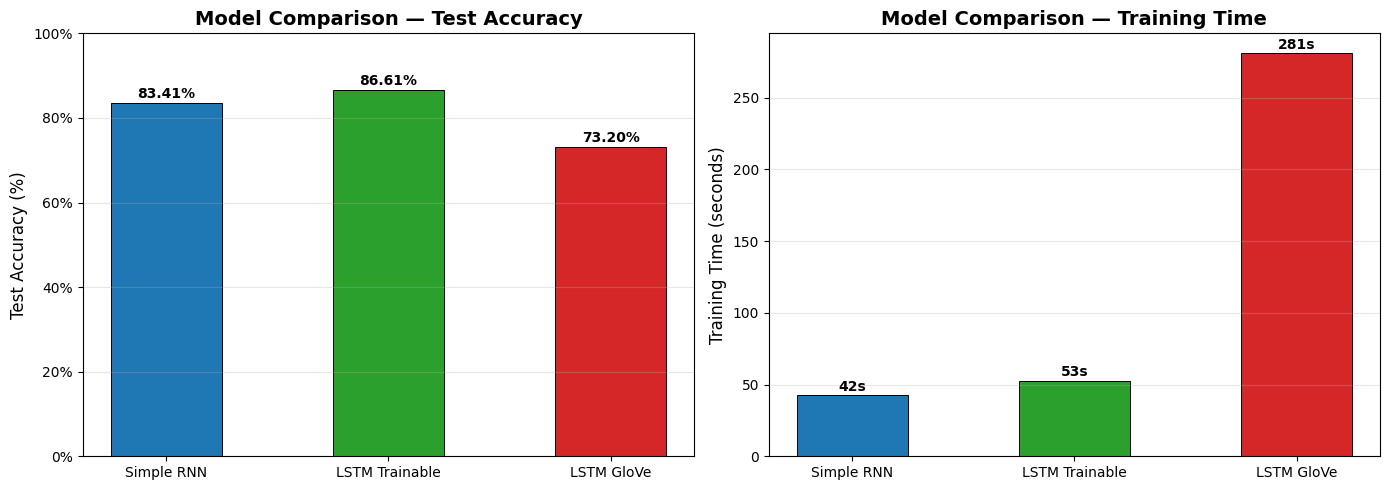


         Model Test Accuracy Train Time (s)              Embedding  Epochs Run
    Simple RNN        83.41%             42     Random (trainable)          15
LSTM Trainable        86.61%             53     Random (trainable)          20
    LSTM GloVe        73.20%            281 GloVe-300 (fine-tuned)          40


In [64]:
# Model comparison: accuracy bar + training time table
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar
colors = ['#1f77b4','#2ca02c','#d62728']
acc_pct = [a*100 for a in accs]
bars = axes[0].bar(NAMES, acc_pct, color=colors, edgecolor='black',
                   linewidth=0.7, width=0.5)
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Model Comparison — Test Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, acc_pct):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Training time bar
axes[1].bar(NAMES, TIMES, color=colors, edgecolor='black', linewidth=0.7, width=0.5)
axes[1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1].set_title('Model Comparison — Training Time', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, (name, t) in enumerate(zip(NAMES, TIMES)):
    axes[1].text(i, t+1, f'{t:.0f}s', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary = pd.DataFrame({
    'Model'          : NAMES,
    'Test Accuracy'  : [f'{a*100:.2f}%' for a in accs],
    'Train Time (s)' : [f'{t:.0f}' for t in TIMES],
    'Embedding'      : ['Random (trainable)', 'Random (trainable)', 'GloVe-300 (fine-tuned)'],
    'Epochs Run'     : [len(h.history['loss']) for h in [h1, h2, h3]]
})
print('\n' + summary.to_string(index=False))



1. Ordinal ambiguity: 3★ vs 4★ reviews often use similar language;
   the boundary is subjective even for humans.
2. Label noise: Amazon star ratings are self-reported — a reviewer who writes
   a positive text may still assign 3★ due to price/delivery issues (out-of-text signal).
3. Short reviews: very brief texts (<10 words after cleaning) give the model
   little signal to distinguish fine-grained sentiment.
4. Sarcasm / negation: 'Could not put it down' is positive; the model may not
   capture such context without attention mechanisms.

 Potential Improvements
• Use a Transformer-based model (e.g., DistilBERT) for richer context.
• Collapse to 3 classes (neg/neu/pos) to reduce ordinal ambiguity.
• Add attention layer to focus on sentiment-bearing tokens.
• Increase EMBED_DIM or use domain-specific embeddings (books corpus).


Best model: LSTM Trainable

Accuracy  : 86.61%
Off-by-1  : 9.49%  (adjacent star — expected for ordinal task)
Off-by-2+ : 3.89%  (large errors)

--- 3 Misclassified Examples ---
True=4★  Pred=3★
  happy new year happy new year enjoyed one quick read get flustered story kind unbelievable still entertaininghunter mason havent seen claire ten year yet want marry love pretty hard believe especially since claire give easilyi liked great quick read

True=3★  Pred=1★
  english humor okay understand english humor okay understand one entertaining little britishenglish humor book accustomed style conversation find light read boring think light pass time well

True=3★  Pred=1★
  slang stereotype ruined great story slang stereotype ruined great story couldve amazing book couldve star author used ridiculous stereotype portraying every character story lost educated main character attended private secondary school ivy league col


--- Why Do Errors Happen? ---
1. Ordinal ambiguity: 3★ vs 4★ reviews o

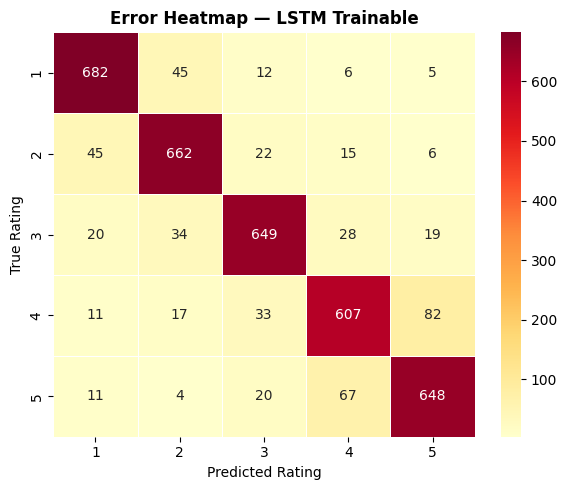

In [61]:
# Error analysis (best model)
best_idx  = int(np.argmax(accs))
best_pred = preds[best_idx]
print(f'Best model: {NAMES[best_idx]}')

err = pd.DataFrame({
    'text': X_te,
    'true': y_te + 1,
    'pred': best_pred + 1
})
err['correct']   = err['true'] == err['pred']
err['abs_error'] = (err['true'] - err['pred']).abs()

print(f'\nAccuracy  : {err["correct"].mean()*100:.2f}%')
print(f'Off-by-1  : {(err["abs_error"]==1).mean()*100:.2f}%  '
      f'(adjacent star — expected for ordinal task)')
print(f'Off-by-2+ : {(err["abs_error"]>=2).mean()*100:.2f}%  (large errors)')

print('\n--- 3 Misclassified Examples ---')
for _, row in err[~err['correct']].sample(3, random_state=SEED).iterrows():
    print(f'True={row["true"]}★  Pred={row["pred"]}★')
    print(f'  {row["text"][:250]}')
    print()

# Error heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    pd.crosstab(err['true'], err['pred'],
                rownames=['True Rating'], colnames=['Predicted Rating']),
    annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title(f'Error Heatmap — {NAMES[best_idx]}', fontweight='bold')
plt.tight_layout()
plt.savefig('error_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


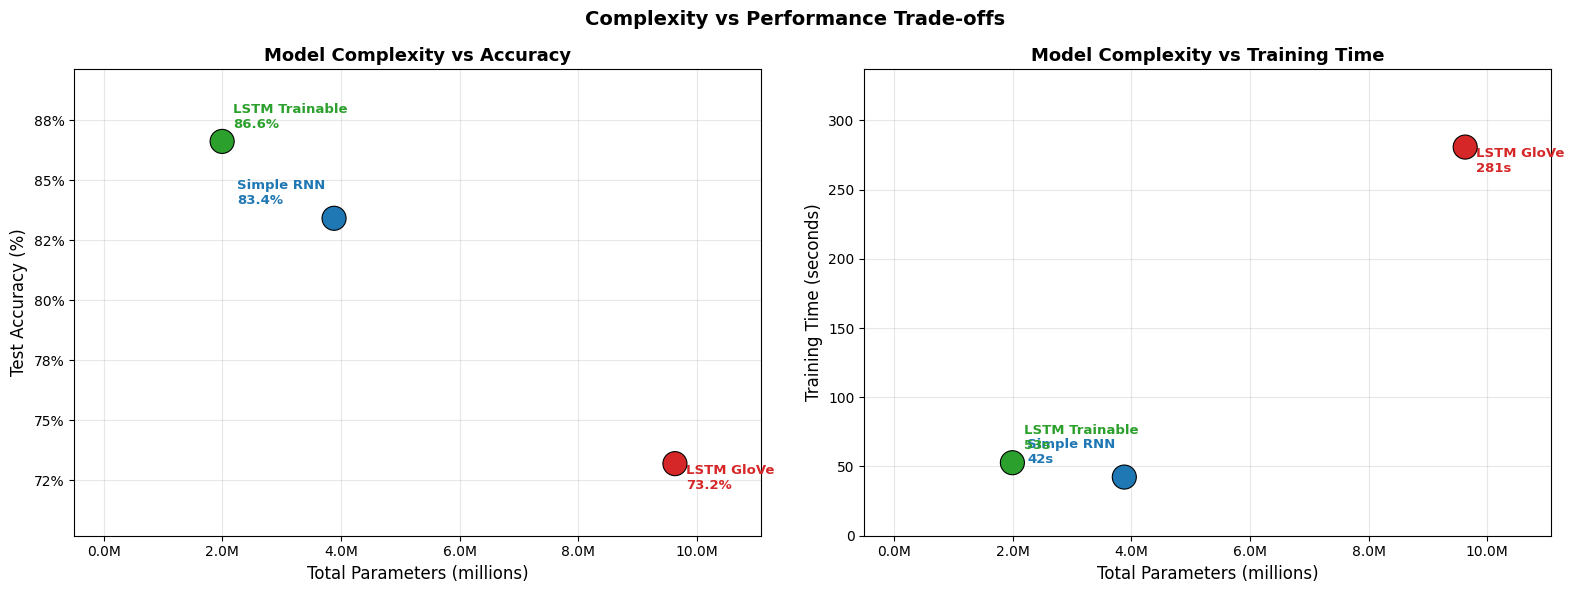

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

COLORS = ['#1f77b4', '#2ca02c', '#d62728']

# Parameters vs Accuracy
axes[0].scatter(param_counts, acc_pct, s=300, color=COLORS, zorder=5,
                edgecolors='black', linewidths=0.8)

# Label offsets per model so they never overlap the dot
offsets = [(-70, 10), (8, 10), (8, -18)]   # LSTM Trainable, Simple RNN, LSTM GloVe
for i, name in enumerate(NAMES):
    axes[0].annotate(f'{name}\n{acc_pct[i]:.1f}%',           # name + value in label
                     (param_counts[i], acc_pct[i]),
                     textcoords='offset points',
                     xytext=offsets[i],
                     fontsize=9.5, fontweight='bold',
                     color=COLORS[i])                          # label colour matches dot

axes[0].set_xlabel('Total Parameters (millions)', fontsize=12)
axes[0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[0].set_title('Model Complexity vs Accuracy', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[0].set_xlim(-0.5e6, max(param_counts) * 1.15)
axes[0].set_ylim(min(acc_pct) - 3, max(acc_pct) + 3)          # tighter y range
axes[0].grid(True, alpha=0.3)

#Parameters vs Training Time
axes[1].scatter(param_counts, TIMES, s=300, color=COLORS, zorder=5,
                edgecolors='black', linewidths=0.8)

for i, name in enumerate(NAMES):
    axes[1].annotate(f'{name}\n{TIMES[i]:.0f}s',
                     (param_counts[i], TIMES[i]),
                     textcoords='offset points',
                     xytext=offsets[i],
                     fontsize=9.5, fontweight='bold',
                     color=COLORS[i])

axes[1].set_xlabel('Total Parameters (millions)', fontsize=12)
axes[1].set_ylabel('Training Time (seconds)', fontsize=12)
axes[1].set_title('Model Complexity vs Training Time', fontsize=13, fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
axes[1].set_xlim(-0.5e6, max(param_counts) * 1.15)
axes[1].set_ylim(0, max(TIMES) * 1.2)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Complexity vs Performance Trade-offs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('complexity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
# Gradio GUI for real-time prediction
import gradio as gr

LABELS = ['1★ Very Negative','2★ Negative','3★ Neutral',
          '4★ Positive',     '5★ Very Positive']

def predict(review, model_choice):
    cleaned = clean_text({'summary': '', 'reviewText': review})
    padded  = pad_sequences(tok.texts_to_sequences([cleaned]),
                            maxlen=MAX_LEN, padding='post', truncating='post')
    mdl = {'Simple RNN':    model1,
           'LSTM Trainable': model2,
           'LSTM GloVe':     model3}[model_choice]
    probs = mdl.predict(padded, verbose=0)[0]
    return {label: float(p) for label, p in zip(LABELS, probs)}

gr.Interface(
    fn=predict,
    inputs=[
        gr.Textbox(lines=4, placeholder='Paste a book review here...',
                   label='Review Text'),
        gr.Radio(['Simple RNN', 'LSTM Trainable', 'LSTM GloVe'],
                 value='LSTM GloVe', label='Choose Model')
    ],
    outputs=gr.Label(num_top_classes=5, label='Predicted Star Rating'),
    title='Book Review Rating Predictor',
    description='Type or paste a book review and select a model to predict the star rating (1–5).'
).launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f933ccc058fd9d3b75.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [68]:
model1.save('/content/drive/MyDrive/Assessment_AI/model1_simplernn.keras')
model2.save('/content/drive/MyDrive/Assessment_AI/model2_lstm_trainable.keras')
model3.save('/content/drive/MyDrive/Assessment_AI/model3_lstm_glove.keras')
print('All 3 models saved to Drive!')

All 3 models saved to Drive!
